In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [3]:
results = pickle.load(open('test_physiology-result_25freqs-pyramidal.pkl', "rb"))


In [4]:
# freq, db, iteration
list(results.keys())[0]

'f0: 4000  dBspl: 20'

In [5]:
fmin = 4e3
fmax = 32e3
octavespacing = 1 / 8.0
# octavespacing = 1.
n_frequencies = int(np.log2(fmax / fmin) / octavespacing) + 1
fvals = (
    np.logspace(
        np.log2(fmin / 1000.0),
        np.log2(fmax / 1000.0),
        num=n_frequencies,
        endpoint=True,
        base=2,
    )
    * 1000.0
)

n_levels = 11
levels = np.linspace(20, 100, n_levels)

In [6]:
fvals, levels

(array([ 4000.        ,  4362.03093066,  4756.82846001,  5187.3582186 ,
         5656.85424949,  6168.84330163,  6727.17132203,  7336.03234564,
         8000.        ,  8724.06186132,  9513.65692002, 10374.71643721,
        11313.70849898, 12337.68660326, 13454.34264406, 14672.06469127,
        16000.        , 17448.12372264, 19027.31384004, 20749.43287442,
        22627.41699797, 24675.37320653, 26908.68528812, 29344.12938255,
        32000.        ]),
 array([ 20.,  28.,  36.,  44.,  52.,  60.,  68.,  76.,  84.,  92., 100.]))

In [7]:
response_map_df = {fval: [0.0 for i in range(len(levels))] for fval in fvals}
response_map_df['dbspl'] = np.flip(levels)
response_map_df = pd.DataFrame.from_dict(response_map_df, orient='columns')
response_map_df.set_index('dbspl', inplace=True)
response_map_df

,4000.000000,4362.030931,4756.828460,5187.358219,5656.854249,6168.843302,6727.171322,7336.032346,8000.000000,8724.061861,...,14672.064691,16000.000000,17448.123723,19027.313840,20749.432874,22627.416998,24675.373207,26908.685288,29344.129383,32000.000000
dbspl,,,,,,,,,,,,,,,,,,,,,
100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
92.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
76.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
baseline = [50, 100]
response = [100, 140]

In [17]:
spont_spikes = 0
spont_time = 0

pop_type = 'pyramidal'
cell_ind = list(results[list(results.keys())[0]][1][0].keys())[0][1]

for stim, iterations in list(results.values()):
    for vec in list(iterations.values()):
        spikes = vec[(pop_type, cell_ind)][1]
        spont_spikes += ((spikes >= baseline[0]) * (spikes < baseline[1])).sum()
        spont_time += baseline[1] - baseline[0]

spont_rate = spont_spikes / spont_time


In [18]:
num_iterations = 1

for stim, iterations in list(results.values()):

    for iteration in range(num_iterations):

        vec = iterations[0]
        spikes = vec[(pop_type, cell_ind)][1]
        n_spikes = ((spikes >= response[0]) & (spikes < response[1])).sum()

        freq = stim.key()['f0']
        level = stim.key()['dbspl']

        # temp = 5

        response_map_df.loc[level, [freq]] += n_spikes - spont_rate * (response[1] - response[0])

response_map_df.div(num_iterations)

# for level, row in response_map_df.iterrows():

#     for freq in fvals:

#         # for iteration in range(num_iterations):
#         key = (freq, level, iteration)
#         result = results[key]

#         spkt = result[1][('bushy',np.int64(4643))][1]

#         spont_spikes += ((spkt >= baseline[0]) * (spkt < baseline[1])).sum()
#         spont_time += baseline[1] - baseline[0]

#         spont_rate = spont_spikes / spont_time

#         resp_spikes = ((spkt >= response[0]) & (spkt < response[1])).sum()

#         response_map_df.loc[level, [freq]] = resp_spikes - spont_rate * (response[1] - response[0])
        


,4000.000000,4362.030931,4756.828460,5187.358219,5656.854249,6168.843302,6727.171322,7336.032346,8000.000000,8724.061861,...,14672.064691,16000.000000,17448.123723,19027.313840,20749.432874,22627.416998,24675.373207,26908.685288,29344.129383,32000.000000
dbspl,,,,,,,,,,,,,,,,,,,,,
100.0,0.613091,3.613091,6.613091,6.613091,6.613091,6.613091,9.613091,6.613091,6.613091,0.613091,...,15.613091,15.613091,9.613091,9.613091,6.613091,6.613091,-2.386909,-11.386909,-2.386909,-5.386909
92.0,3.613091,-8.386909,3.613091,0.613091,3.613091,3.613091,0.613091,6.613091,6.613091,6.613091,...,12.613091,9.613091,9.613091,9.613091,6.613091,-5.386909,-11.386909,-5.386909,-11.386909,-2.386909
84.0,-8.386909,0.613091,-2.386909,0.613091,-2.386909,-2.386909,-2.386909,0.613091,6.613091,6.613091,...,12.613091,9.613091,9.613091,6.613091,3.613091,-11.386909,-17.386909,-8.386909,-5.386909,-5.386909
76.0,-5.386909,0.613091,0.613091,-2.386909,-5.386909,-11.386909,-2.386909,-11.386909,-5.386909,-5.386909,...,15.613091,15.613091,9.613091,3.613091,-5.386909,-8.386909,-5.386909,-5.386909,-2.386909,-2.386909
68.0,0.613091,-2.386909,-5.386909,-5.386909,-2.386909,-2.386909,-8.386909,-2.386909,-11.386909,-5.386909,...,12.613091,12.613091,9.613091,0.613091,-11.386909,-8.386909,-5.386909,-5.386909,0.613091,-2.386909
60.0,-5.386909,-2.386909,-2.386909,-5.386909,-5.386909,-5.386909,-11.386909,-8.386909,-11.386909,-8.386909,...,12.613091,6.613091,3.613091,-2.386909,-8.386909,-5.386909,-5.386909,0.613091,-2.386909,-8.386909
52.0,0.613091,-5.386909,-2.386909,-2.386909,-2.386909,-2.386909,-2.386909,-2.386909,-8.386909,-8.386909,...,9.613091,15.613091,6.613091,-5.386909,-8.386909,-8.386909,-5.386909,-5.386909,-2.386909,-2.386909
44.0,-5.386909,-5.386909,-2.386909,0.613091,-2.386909,-5.386909,-5.386909,0.613091,-2.386909,-2.386909,...,12.613091,12.613091,0.613091,-2.386909,-2.386909,-11.386909,-5.386909,-5.386909,0.613091,-2.386909
36.0,-2.386909,0.613091,-2.386909,-5.386909,-5.386909,-2.386909,-5.386909,0.613091,-5.386909,-2.386909,...,12.613091,12.613091,-2.386909,-5.386909,-8.386909,-2.386909,0.613091,0.613091,3.613091,0.613091


In [19]:
response_map_df

,4000.000000,4362.030931,4756.828460,5187.358219,5656.854249,6168.843302,6727.171322,7336.032346,8000.000000,8724.061861,...,14672.064691,16000.000000,17448.123723,19027.313840,20749.432874,22627.416998,24675.373207,26908.685288,29344.129383,32000.000000
dbspl,,,,,,,,,,,,,,,,,,,,,
100.0,0.613091,3.613091,6.613091,6.613091,6.613091,6.613091,9.613091,6.613091,6.613091,0.613091,...,15.613091,15.613091,9.613091,9.613091,6.613091,6.613091,-2.386909,-11.386909,-2.386909,-5.386909
92.0,3.613091,-8.386909,3.613091,0.613091,3.613091,3.613091,0.613091,6.613091,6.613091,6.613091,...,12.613091,9.613091,9.613091,9.613091,6.613091,-5.386909,-11.386909,-5.386909,-11.386909,-2.386909
84.0,-8.386909,0.613091,-2.386909,0.613091,-2.386909,-2.386909,-2.386909,0.613091,6.613091,6.613091,...,12.613091,9.613091,9.613091,6.613091,3.613091,-11.386909,-17.386909,-8.386909,-5.386909,-5.386909
76.0,-5.386909,0.613091,0.613091,-2.386909,-5.386909,-11.386909,-2.386909,-11.386909,-5.386909,-5.386909,...,15.613091,15.613091,9.613091,3.613091,-5.386909,-8.386909,-5.386909,-5.386909,-2.386909,-2.386909
68.0,0.613091,-2.386909,-5.386909,-5.386909,-2.386909,-2.386909,-8.386909,-2.386909,-11.386909,-5.386909,...,12.613091,12.613091,9.613091,0.613091,-11.386909,-8.386909,-5.386909,-5.386909,0.613091,-2.386909
60.0,-5.386909,-2.386909,-2.386909,-5.386909,-5.386909,-5.386909,-11.386909,-8.386909,-11.386909,-8.386909,...,12.613091,6.613091,3.613091,-2.386909,-8.386909,-5.386909,-5.386909,0.613091,-2.386909,-8.386909
52.0,0.613091,-5.386909,-2.386909,-2.386909,-2.386909,-2.386909,-2.386909,-2.386909,-8.386909,-8.386909,...,9.613091,15.613091,6.613091,-5.386909,-8.386909,-8.386909,-5.386909,-5.386909,-2.386909,-2.386909
44.0,-5.386909,-5.386909,-2.386909,0.613091,-2.386909,-5.386909,-5.386909,0.613091,-2.386909,-2.386909,...,12.613091,12.613091,0.613091,-2.386909,-2.386909,-11.386909,-5.386909,-5.386909,0.613091,-2.386909
36.0,-2.386909,0.613091,-2.386909,-5.386909,-5.386909,-2.386909,-5.386909,0.613091,-5.386909,-2.386909,...,12.613091,12.613091,-2.386909,-5.386909,-8.386909,-2.386909,0.613091,0.613091,3.613091,0.613091


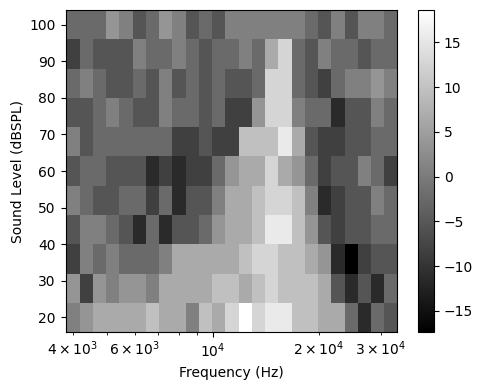

In [28]:
fig, axs = plt.subplots(1,1,figsize=(5,4))

im = axs.pcolormesh(fvals, levels, response_map_df.values, cmap=cm.grey)
# axs.invert_yaxis()
axs.set_xlabel('Frequency (Hz)')
axs.set_ylabel('Sound Level (dBSPL)')
axs.set_xscale('log')
# axs.set_xticks([4e3, 9e3, 20e3, 30e3])
# axs.set_xticklabels([4, 8, 16, 32])
fig.colorbar(im)
fig.tight_layout()


array([ 8.29404964,  8.38069304,  8.46733644,  8.55397983,  8.64062323,
        8.72726663,  8.81391003,  8.90055342,  8.98719682,  9.07384022,
        9.16048362,  9.24712701,  9.33377041,  9.42041381,  9.50705721,
        9.5937006 ,  9.680344  ,  9.7669874 ,  9.8536308 ,  9.94027419,
       10.02691759, 10.11356099, 10.20020439, 10.28684778, 10.37349118])